# Solar Share Historical — Data Ingestion & Artifact Creation

## Objective
Encode the **Italian national** annual solar share of total generation
(2005-2025) and derive a **penetration index** normalised to 2025
(pen = 1.0 = 13.0%). Saves a single parquet artifact consumed by every
downstream modelling notebook.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| Manual series — GSE / Terna annual statistics | Encode, normalise, persist | `Data/Cleaned/df_solar_share.parquet` |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D1 | Italy national aggregate | NORD zone only | Series is the national solar share of total generation; the price side remains NORD-zonal | Penetration is a system-wide driver, not a zonal one — mixing scopes is intentional and documented |
| D2 | `REFERENCE_SHARE = 13.0%` (2025) | 2024 (11.5%), 2020 baseline | 2025 is the latest and highest observed year; pen = 1.0 anchors the index at current penetration | No historical year exceeds pen = 1.0; matches `Solar share paths.ipynb`, which already anchors on the 2025 peak |
| D3 | 2025 share = 13.0% treated as **observed** | Flag as projected | Taken as a settled GSE/Terna figure | Downstream notebooks need no "estimated" caveat for 2025 |
| D4 | Values hard-coded in this notebook | Parse GSE/Terna PDFs programmatically | Series is 21 annual scalars, revised at most once a year | Any restatement must be edited here by hand, then re-run |

> **Caveat on three consecutive identical years.** 2020, 2021 and 2022 all
> carry exactly 9.50%, and 2024 (11.50%) sits below 2023 (12.30%) despite a
> period of strong Italian PV capacity growth. These are the values as
> published; no per-year citation beyond the blanket `source = "GSE/Terna"`
> field is recorded here. Since this series sets `lambda_decay` in the
> capture-rate model and every downstream hedge premium, verify the
> 2020-2024 figures against a primary GSE/Terna source before treating the
> capture-rate projections as final.

Load standard libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Set output paths; create directories if absent.

In [2]:
output_path = Path("../../Data/Cleaned")
output_path.mkdir(parents=True, exist_ok=True)

Hard-code the Italian national annual solar share series (D1, D4) and set the normalisation anchor to 2025 (D2, D3).

In [3]:
# ── solar share data ──────────────────────────────────────────────────────────
solar_share_pct = {   # D1: Italy national — D4: manually encoded from GSE/Terna PDFs
    2005:  0.02,
    2006:  0.03,
    2007:  0.05,
    2008:  0.10,
    2009:  0.26,
    2010:  0.63,
    2011:  3.00,
    2012:  5.70,
    2013:  7.40,
    2014:  7.90,
    2015:  7.80,
    2016:  7.90,
    2017:  7.70,
    2018:  7.90,
    2019:  8.60,
    2020:  9.50,
    2021:  9.50,
    2022:  9.50,
    2023: 12.30,
    2024: 11.50,
    2025: 13.00,  # D3: observed
}

# D2: 2025 is the normalisation anchor — pen = 1.0
REFERENCE_YEAR  = 2025
REFERENCE_SHARE = solar_share_pct[REFERENCE_YEAR]   # 13.0%

Assemble `DataFrame` and compute `penetration_index = solar_share_pct / REFERENCE_SHARE` (D2) — so `pen = 1.0` in 2025.

In [4]:
# ── build dataframe ───────────────────────────────────────────────────────────
df_solar_share = pd.DataFrame({
    "year":              list(solar_share_pct.keys()),
    "solar_share_pct":   list(solar_share_pct.values()),
})
 
df_solar_share["penetration_index"] = (
    df_solar_share["solar_share_pct"] / REFERENCE_SHARE
)
df_solar_share["reference_share_pct"] = REFERENCE_SHARE
df_solar_share["reference_year"]      = REFERENCE_YEAR
df_solar_share["source"]              = "GSE/Terna"
df_solar_share["zone"]                = "ITALY"
df_solar_share["notes"]               = (
    "national solar share of total generation; "
    "penetration_index = solar_share_pct / reference_share_pct  "
    f"(pen=1.0 at {REFERENCE_YEAR})"
)

Persist artifact to parquet for downstream consumption.

In [5]:
# ── save ──────────────────────────────────────────────────────────────────────
out_file = output_path / "df_solar_share.parquet"
df_solar_share.to_parquet(out_file, index=False)
 
print("── Solar share data saved ────────────────────────────────────────")
print(f"  Path  : {out_file.resolve()}")
print(f"  Rows  : {len(df_solar_share)}")
print(f"  Cols  : {list(df_solar_share.columns)}")
print(f"  Scope : Italy national — solar share of total generation")
print(f"\n  Reference share : {REFERENCE_SHARE}% ({REFERENCE_YEAR} = pen=1.0)")
print(f"\n  Preview:")
print(df_solar_share[["year","solar_share_pct","penetration_index"]]
      .to_string(index=False))

── Solar share data saved ────────────────────────────────────────
  Path  : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Cleaned\df_solar_share.parquet
  Rows  : 21
  Cols  : ['year', 'solar_share_pct', 'penetration_index', 'reference_share_pct', 'reference_year', 'source', 'zone', 'notes']
  Scope : Italy national — solar share of total generation

  Reference share : 13.0% (2025 = pen=1.0)

  Preview:
 year  solar_share_pct  penetration_index
 2005             0.02           0.001538
 2006             0.03           0.002308
 2007             0.05           0.003846
 2008             0.10           0.007692
 2009             0.26           0.020000
 2010             0.63           0.048462
 2011             3.00           0.230769
 2012             5.70           0.438462
 2013             7.40           0.569231
 2014             7.90           0.607692
 2015             7.80           0.600000
 2016             7.90           0.60769

## Visual check — evolution of the solar share

Plot the Italian national solar share of total generation (2005–2025) as a single observed
series, with the `REFERENCE_SHARE` level (pen = 1.0 at 2025, D2) marked for orientation.

[SAVED] C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Results\fig_solar_share_historical.pdf (+ .png)


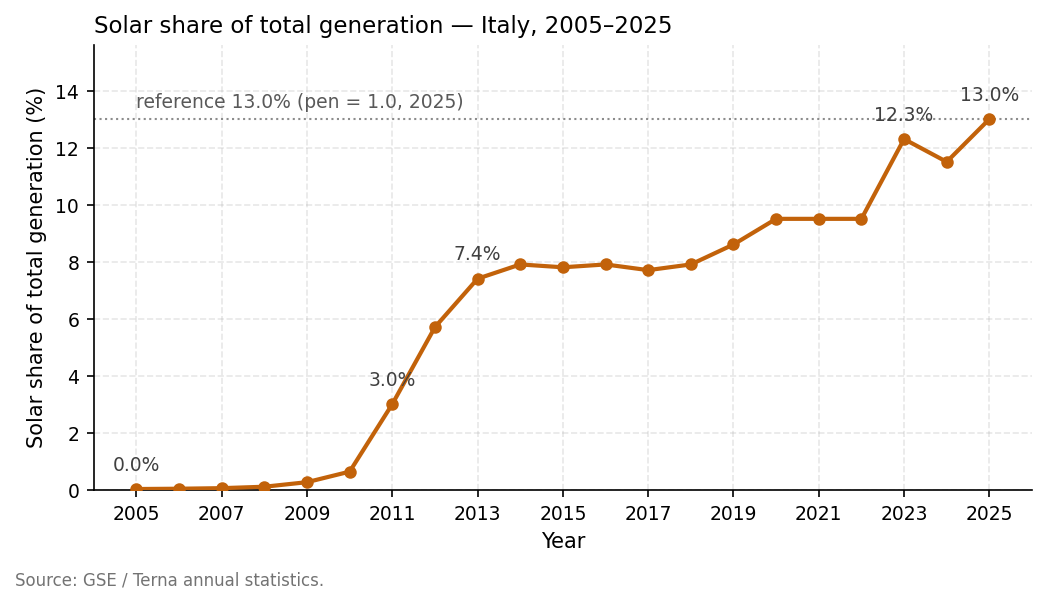

In [6]:
# ── plot: solar share evolution ───────────────────────────────────────────────
# House style — matches "EDA - Energy Prices.ipynb" so all thesis figures agree
plt.rcParams.update({
    "figure.dpi":      150,
    "savefig.dpi":     300,
    "figure.facecolor": "white",
    "axes.facecolor":  "white",
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "grid.linestyle":  "--",
    "font.size":       10,
    "axes.titlesize":  11,
    "axes.labelsize":  10,
    "legend.fontsize":  9,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
})

SOLAR        = "#C2620A"   # single series — one hue
IN_FIG_TITLE = True        # set False when exporting — the LaTeX caption carries it

# 7x4 in ≈ 16 cm — fits an A4 text block at 100% scale, so fonts print at their set size
fig, ax = plt.subplots(figsize=(7, 4))

# observed series, 2005–2025 (one series ⇒ no legend; the title names it)
ax.plot(df_solar_share["year"], df_solar_share["solar_share_pct"],
        color=SOLAR, lw=2, marker="o", ms=5, zorder=3)

# normalisation anchor (pen = 1.0, D2)
ax.axhline(REFERENCE_SHARE, color="0.55", lw=1, ls=":", zorder=1)
ax.text(df_solar_share["year"].min(), REFERENCE_SHARE + 0.25,
        f"reference {REFERENCE_SHARE}% (pen = 1.0, {REFERENCE_YEAR})",
        color="0.35", fontsize=9, va="bottom")

# selective direct labels: start of series, the 2011-13 ramp, and the endpoints
for yr in (2005, 2011, 2013, 2023, 2025):
    row = df_solar_share.loc[df_solar_share["year"] == yr].iloc[0]
    ax.annotate(f"{row.solar_share_pct:.1f}%",
                (row.year, row.solar_share_pct),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, color="0.25")

if IN_FIG_TITLE:
    ax.set_title("Solar share of total generation — Italy, 2005–2025", loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Solar share of total generation (%)")
ax.set_xticks(range(2005, 2026, 2))
ax.set_ylim(0, df_solar_share["solar_share_pct"].max() * 1.20)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

# source note — thesis figures should carry provenance
fig.text(0.01, 0.005, "Source: GSE / Terna annual statistics.",
         fontsize=8, color="0.45", ha="left", va="bottom")

fig.tight_layout(rect=(0, 0.03, 1, 1))

plt.show()

> **Takeaway.** The series is flat and near-zero through 2010, ramps sharply
> in 2011-2013 (the Italian feed-in-tariff boom), then plateaus around 8-9.5%
> for most of the 2014-2022 period before the 2023-2025 uptick to 13%. The
> flat 2020-2022 stretch and the 2023-to-2024 dip are visible here exactly as
> flagged in the Decision Log above — worth a second look against a primary
> source before relying on the shape of this ramp.

## Conclusion & Handoff

- **Italian national** solar share of total generation (2005-2025) encoded
  and normalised to a penetration index (pen = 1.0 at 13.0%, 2025 baseline
  — D2).
- All 21 years, **2025 included, are treated as observed** (D3); no year
  carries an "estimated" caveat, though 2020-2024 warrant verification (see
  the caveat above).
- Scope note: penetration is national (D1) while the price side of the
  thesis remains NORD-zonal — the mixed scope is deliberate, since PV
  penetration drives the Italian system as a whole.

**Next notebook can rely on:** `Data/Cleaned/df_solar_share.parquet` —
columns `year`, `solar_share_pct`, `penetration_index`, `reference_share_pct`,
`reference_year`, `source`, `zone`, `notes`. Consistent with
`Code/Scenarios/02_solar_share_paths.ipynb`, which already anchors its
scenarios on the 2025 share of 13.0% (pen(2026) = 1.0), and read by
`Code/Modelling/05_capture_rate.ipynb`.